# BMC statistical analysis: comparing collected spectra to literature references

In [1]:
# imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import scipy.stats

# Load collected spectra

In [2]:
BASE_PATH = '/Users/melissa/Library/CloudStorage/OneDrive-UniversityofCambridge/PhD/Lab work/Biomolecule characterisation/Data_and_Code/'

# Shimadzu SIS data
PATH_SHIMADZU = BASE_PATH + 'Data/Shimadzu/processed_Shimadzu_spectra.csv'
shimadzu = np.genfromtxt(PATH_SHIMADZU, delimiter=',', names=True, dtype=None)
print('Shimadzu column names: ', shimadzu.dtype.names)

# in-house SIS data
PATH_inhouse_SIS = BASE_PATH + 'Data/in-house-SIS/processed_in-house_spectra.csv'
inhouseSIS = np.genfromtxt(PATH_inhouse_SIS, delimiter=',', names=True, dtype=None)
print('\n')
print('in-house SIS column names: ', inhouseSIS.dtype.names)

# Ran Tao's H2O data
PATH_Tao_H2O = BASE_PATH + 'Data/in-house-SIS/H2O_Tao/H2O_Tao_mua_only.csv'
Tao_H2O = np.genfromtxt(PATH_Tao_H2O, delimiter=',', names=True, dtype=None)
print('\n')
print('H2O by Tao in in-house SIS column names: ', Tao_H2O.dtype.names)

Shimadzu column names:  ('nm', 'H2O_mua', 'H2O_std', 'DMSO_mua', 'DMSO_std', 'D2O_mua', 'D2O_std', 'melanin_mua', 'melanin_std', 'corn_oil_mua', 'corn_oil_std', 'HbO2_mua', 'HbO2_std', 'Hb_mua', 'Hb_std', 'melanin_DMSO_mua', 'melanin_DMSO_std')


in-house SIS column names:  ('nm', 'lard_mua', 'lard_mua_std', 'lard_mus', 'lard_mus_std', 'lard_mus_fit', 'lard_musp', 'lard_musp_std', 'lard_g', 'WB_S_oxy_mua', 'WB_S_oxy_mua_std', 'WB_S_deoxy_mua', 'WB_S_deoxy_mua_std', 'WB_oxy_mua', 'WB_oxy_mua_std', 'WB_oxy_mus', 'WB_oxy_mus_std', 'WB_oxy_mus_fit', 'WB_oxy_musp', 'WB_oxy_musp_std', 'WB_oxy_g', 'WB_deoxy_mua', 'WB_deoxy_mua_std', 'WB_deoxy_mus', 'WB_deoxy_mus_std', 'WB_deoxy_mus_fit', 'WB_deoxy_musp', 'WB_deoxy_musp_std', 'WB_deoxy_g', 'copolymer_mua', 'copolymer_mua_std', 'copolymer_mus', 'copolymer_mus_std', 'copolymer_mus_fit', 'copolymer_musp', 'copolymer_musp_std', 'copolymer_g', 'agar_mua', 'agar_mua_std', 'agar_mus', 'agar_mus_std', 'agar_mus_fit', 'agar_musp', 'agar_musp_std', 'aga

Find ranges of measured spectra by manually looking at the csv file:

Shimadzu:

H2O: 920 - 1898nm

DMSO: 

D2O: 510 - 586nm, 632 - 2500nm

Melanin - DMSO: 260 - 2248nm

Corn oil: 292 - 532nm, 880 - 2500nm

HbO2: 250 - 396nm, 428 - 872nm, 906 - 2500nm

Hb: 250 - 406nm, 438 - 874nm, 906 - 2500nm


Ran SIS:

Lard mua: 450 - 542nm, 877 - 1599nm
Lard mus: 240 - 1599nm

WB OXY 1% mua: 450 - 600nm

WB OXY: 600 - 1599nm

WB DEOXY 1%: 450 - 600nm

WB DEOXY 600 - 1599nm

# Load literature references

In [3]:
# load spectra from literature

# Prahl HbO2 and Hb ref
PATH_Hb = BASE_PATH + 'Data/Reference_Spectra/Hb_HbO2_spectra.txt'
Hb_file = pd.read_csv(PATH_Hb, delimiter='\t', header=[0, 1]) # note: extinction spectra
Hb_abs_const =  2.303 * 150 /64500 # 150 g Hb/litre, 64500 g Hb/mole (typical values from Prahl ref)
HbO2_mua_ref = np.squeeze(Hb_file['Hb02']) * Hb_abs_const
HbO2_wavelengths_ref = np.squeeze(Hb_file['lambda'])
Hb_mua_ref = np.squeeze(Hb_file['Hb']) * Hb_abs_const
Hb_wavelengths_ref = np.squeeze(Hb_file['lambda'])

# Seglestein water
PATH_water = BASE_PATH + 'Data/Reference_Spectra/water_spectrum.txt'
water_data = pd.read_csv(PATH_water, delimiter='\t', header=[0, 1]) # in cm-1
water_wavelengths_ref = np.squeeze(water_data['lambda'])
water_mua_ref = np.squeeze(water_data['absorption'])

# D2O, wavelength in um, k (extinction coefficient)
PATH_D2O = BASE_PATH + 'Data/Reference_Spectra/D2O_k_Kedenburg2012.txt'
D2O_data = pd.read_csv(PATH_D2O, sep=',')
D2O_nm_ref = D2O_data['wl']*1e3 # convert um to nm
D2O_mua_ref = D2O_data['k']*4*np.pi/D2O_nm_ref*1e7 # convert k (entinction coefficient) to mua

# Blood musp
PATH_blood_musp = BASE_PATH + 'Data/Reference_Spectra/blood_musp.txt'
blood_musp_ref = pd.read_csv(PATH_blood_musp, sep='\t')

# SWIR whole blood mua and mus and g, Bosschaart 2013
PATH_SWIRblood = BASE_PATH + 'Data/Reference_Spectra/whole_blood_SWIR_literature.csv'
whole_blood_ref = pd.read_csv(PATH_SWIRblood, sep=",", header=[0])
whole_blood_ref['nm'] = whole_blood_ref['nm'].str.replace(',', '').astype(float) # wavelengths over 1000nm have commas (e.g. 1,005nm) so convert to float
whole_blood_ref = whole_blood_ref[whole_blood_ref['nm'] < 1650.0]
whole_blood_ref = whole_blood_ref[whole_blood_ref['nm'] > 450.0]

# FAT: Pig fat (VIS - NIR data to 1098nm, van Veen) + Human fat (SWIR, Anderson 2006)
PATH_fat = BASE_PATH + 'Data/Reference_Spectra/' + 'pig_and_human_fat_mua.txt'
fat_ref = pd.read_csv(PATH_fat, sep='\t')

# Melanin 
PATH_melanin = BASE_PATH + 'Data/Reference_Spectra/melanin_mua_SIMPA_ext.txt' # melanosome approximation
melanin_mua_ref = pd.read_csv(PATH_melanin, sep='\t')
PATH_Jacques_1991 = BASE_PATH + 'Data/Reference_Spectra/Jacques_melanin_1991_data.csv' # individual data points
Jacques_1991_mua = pd.read_csv(PATH_Jacques_1991, sep=',')

# Fat mus
PATH_fat_musp = BASE_PATH + 'Data/Reference_Spectra/fat_musp.txt'
fat_musp_ref = pd.read_csv(PATH_fat_musp, sep='\t')

# Plot spectra to choose region to analyse

In [4]:
# plots mua and ± standard deviation from df_merged (Shimadzu spectrophotometer data)
def plot_mua(df, mua_column_name, std_column_name, colour, label):

    plt.figure(figsize=(6,3))
    plt.plot(df['nm'], df[mua_column_name], c=colour, lw=2, ls='-', label=label)
    plt.fill_between(df['nm'], df[mua_column_name] - df[std_column_name], df[mua_column_name] 
                     + df[std_column_name], color=colour, lw=2, alpha=0.3, edgecolor=None)
    
    plt.grid(True)
    plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha = 0.5)
    plt.yscale("log")

    plt.ylabel('$\mu_a$ (cm$^{-1}$)',  fontsize=14)
    plt.xlabel('Wavelength (nm)',  fontsize=14)
    plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True, bottom=True)
    plt.minorticks_on()

    return

# Statistical tests: Spectral Angle Mapping (SAM), Pearson's correlation and PSNR

In [25]:
# create array with common wavelength axis to compare measured and literature datasets 
#(remove wavelength data that is not common to both / fit to 2nm interval I measured with)
def interpolate(x_min, x_max, interval, x_measured, y_measured, y_measured_std, x_literature, y_literature):

    x_new = np.arange(x_min, x_max+interval, interval)

    y_measured = np.interp(x_new, x_measured, y_measured)
    y_measured_std = np.interp(x_new, x_measured, y_measured_std)

    y_literature = np.interp(x_new, x_literature, y_literature)

    x_new = x_new[~np.isnan(y_measured)]
    y_measured_std = y_measured_std[~np.isnan(y_measured)]
    y_literature = y_literature[~np.isnan(y_measured)]
    y_measured = y_measured[~np.isnan(y_measured)]
    
    return x_new, y_measured, y_measured_std, y_literature

# plot interpolated spectra
def plot_interp(x_new, y_measured, y_measured_std, y_literature, colour, label):

    plt.figure(figsize=(5,3))
    
    # measured
    plt.plot(x_new, y_measured, c=colour, ls='', marker='.', markersize=2, label=label)
    plt.fill_between(x_new, y_measured - y_measured_std, y_measured
                     + y_measured_std, color=colour, lw=2, alpha=0.3, edgecolor=None)

    #literature
    plt.plot(x_new, y_literature, c='grey', ls='', marker='.', markersize=2, label='Literature')
    
    plt.yscale("log")
    plt.ylabel('$\mu_a$ (cm$^{-1}$)',  fontsize=14)
    plt.xlabel('Wavelength (nm)',  fontsize=14)
    plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True, bottom=True)
    plt.minorticks_on()
    plt.legend(loc=0, fontsize=9)

    return
#------------------------------------------------------------------------------------------------------------------------------------------

# Spectral angle mapping (SAM)  
def SAM(spectrum,reference):
    
    theta = math.acos(sum(spectrum*reference)/(np.sqrt(sum(spectrum**2))*np.sqrt(sum(reference**2))))
    
    return theta

# insert mean as spectrum
def SAM_score(spectrum, reference, spectrum_std):
    
    theta = SAM(spectrum, reference)
    
    SAM_upper = SAM(spectrum - spectrum_std, reference)
    SAM_lower = SAM(spectrum + spectrum_std, reference)

    # uncertainty
    error = abs((SAM_upper - SAM_lower)/2)
    
    print('SAM score is', round(theta,4), '±', round(error,4))

    return theta, error
    
#------------------------------------------------------------------------------------------------------------------------------------------

# Pearson's r measures the linear relationship between two datasets
def pearson(spectrum,reference):

    res = scipy.stats.pearsonr(spectrum,reference)

    CI = res.confidence_interval(confidence_level=0.95)
    
    print('Pearsons r = ', round(res[0],4), ' & p = ', round(res[1],4), ' 95% CI = [', round(CI[0], 4), round(CI[1], 4), ']')
        
    return res[0], res[1], CI[0], CI[1]

#------------------------------------------------------------------------------------------------------------------------------------------
# root mean square error (RMSE)
def RMSE(measured, literature, measured_std):

    mse = np.mean(np.square(np.subtract(measured, literature))) # mean square error
    rmse = np.sqrt(mse) # root mean square error

    rmse_upper = np.sqrt(np.mean(np.square(np.subtract((measured+measured_std), literature))))
    rmse_lower = np.sqrt(np.mean(np.square(np.subtract((measured-measured_std), literature))))

    error = abs((rmse_upper - rmse_lower)/2)

    print('RMSE = ', round(rmse, 1), ' ± ', round(error, 1))

    return rmse, error
#------------------------------------------------------------------------------------------------------------------------------------------

def run_stats(y_measured, y_measured_std, y_literature, name):

    # Spectral angle mapping (SAM)
    SAM, SAM_uncertainty = SAM_score(y_measured, y_literature, y_measured_std)
    
    # Pearson's r
    r, p, CI_lower, CI_upper = pearson(y_measured, y_literature)

    # RMSE
    rmse, rmse_error = RMSE(y_measured, y_literature, y_measured_std)

    stats = [name, round(SAM, 5), round(SAM_uncertainty, 5), round(r, 3), round(p, 3), round(CI_lower, 3), round(CI_upper, 3), 
             round(rmse, 3), round(rmse_error, 3)]

    return stats



SAM score is 0.1074 ± 0.0007
Pearsons r =  0.9909  & p =  0.0  95% CI = [ 0.9885 0.9927 ]
RMSE =  1.3  ±  0.0


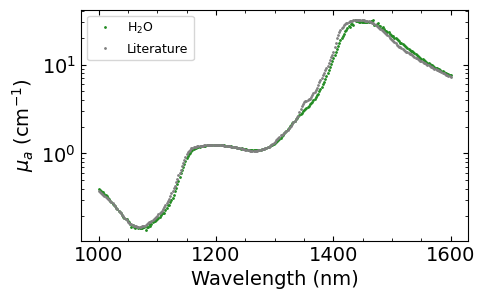

In [26]:
## WATER 1000-1600nm

#940, 1890,
H2O_wvl, H2O_meas, H2O_meas_std, H2O_lit = interpolate(1000, 1600, 2, shimadzu['nm'], shimadzu['H2O_mua'], shimadzu['H2O_std'], water_wavelengths_ref, water_mua_ref)

# plot
plot_interp(H2O_wvl, H2O_meas, H2O_meas_std, H2O_lit, 'forestgreen', 'H$_2$O')

# stats 
H2O_stats_SWIR = run_stats(H2O_meas, H2O_meas_std, H2O_lit, 'H2O_SWIR')     

SAM score is 0.0968 ± 0.0028
Pearsons r =  0.9929  & p =  0.0  95% CI = [ 0.9912 0.9944 ]
RMSE =  1.7  ±  0.0


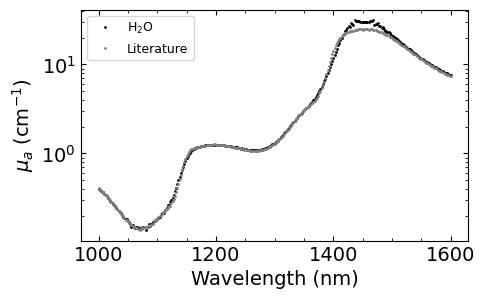

In [27]:
## WATER 1000-1600nm COMAPRE SHIMADZU WITH RAN SIS SYSTEMS

#940, 1890,
H2O_wvl2, H2O_meas2, H2O_meas_std2, H2O_lit2 = interpolate(1000, 1600, 2, shimadzu['nm'], shimadzu['H2O_mua'], shimadzu['H2O_std'], Tao_H2O['nm'], Tao_H2O['muacm1'])

# plot
plot_interp(H2O_wvl2, H2O_meas2, H2O_meas_std2, H2O_lit2, 'k', 'H$_2$O')

# stats 
H2O_stats_SWIR2 = run_stats(H2O_meas2, H2O_meas_std2, H2O_lit2, 'H2O_SWIR_Shimadzu-Ran')

SAM score is 0.1218 ± 0.0002
Pearsons r =  0.9886  & p =  0.0  95% CI = [ 0.9857 0.9909 ]
RMSE =  2.1  ±  0.0


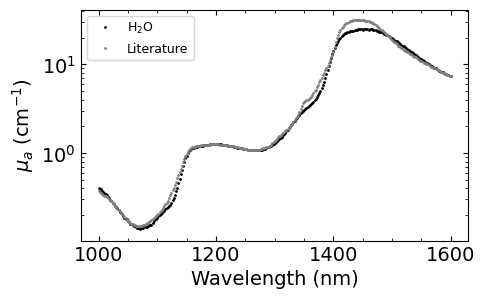

In [28]:
## WATER 1000-1600nm COMAPRE RAN SIS WITH SEGELSTEIN

#940, 1890,
H2O_wvl3, H2O_meas3, H2O_meas_std3, H2O_lit3 = interpolate(1000, 1600, 2, Tao_H2O['nm'], Tao_H2O['muacm1'], Tao_H2O['mua_stdcm1'], water_wavelengths_ref, water_mua_ref)

# plot
plot_interp(H2O_wvl3, H2O_meas3, H2O_meas_std3, H2O_lit3, 'k', 'H$_2$O')

# stats 
H2O_stats_SWIR3 = run_stats(H2O_meas3, H2O_meas_std3, H2O_lit3, 'H2O_SWIR_Ran-Segelstein')


SAM score is 0.1341 ± 0.0346
Pearsons r =  0.9613  & p =  0.0  95% CI = [ 0.9303 0.9787 ]
RMSE =  0.0  ±  0.0


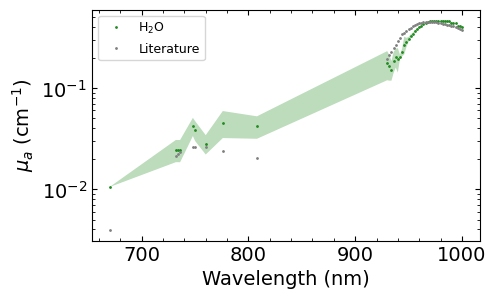

In [29]:
## WATER 450-1000nm

#940, 1890,
H2O_wvl, H2O_meas, H2O_meas_std, H2O_lit = interpolate(450, 1000, 2, shimadzu['nm'], shimadzu['H2O_mua'], shimadzu['H2O_std'], water_wavelengths_ref, water_mua_ref)

# plot
plot_interp(H2O_wvl, H2O_meas, H2O_meas_std, H2O_lit, 'forestgreen', 'H$_2$O')

# stats 
H2O_stats_vis = run_stats(H2O_meas, H2O_meas_std, H2O_lit, 'H2O_vis')     

SAM score is 0.0994 ± 0.0004
Pearsons r =  0.9919  & p =  0.0  95% CI = [ 0.9899 0.9936 ]
RMSE =  0.0  ±  0.0


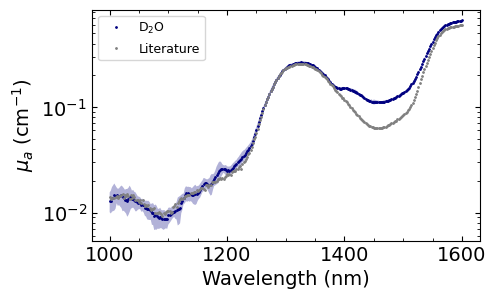

In [30]:
# D2O

#940, 1890,
D2O_wvl, D2O_meas, D2O_meas_std, D2O_lit = interpolate(1000, 1600, 2, shimadzu['nm'], shimadzu['D2O_mua'], shimadzu['D2O_std'], D2O_nm_ref, D2O_mua_ref)

# plot
plot_interp(D2O_wvl, D2O_meas, D2O_meas_std, D2O_lit, 'navy', 'D$_2$O')

# stats 
D2O_stats = run_stats(D2O_meas, D2O_meas_std, D2O_lit, 'D2O_SWIR')



SAM score is 0.0427 ± 0.0027
Pearsons r =  0.9988  & p =  0.0  95% CI = [ 0.9982 0.9992 ]
RMSE =  15.9  ±  1.1


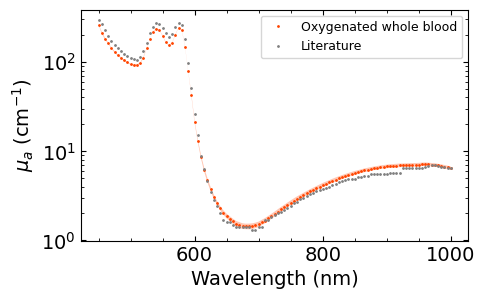

In [31]:
# WHOLE BLOOD OXY

#450 - 1599nm
WB_OXY_wvl, WB_OXY_meas, WB_OXY_meas_std, WB_OXY_lit = interpolate(450, 1000, 5, inhouseSIS['nm'], inhouseSIS['WB_S_oxy_mua'], inhouseSIS['WB_S_oxy_mua_std'], whole_blood_ref['nm'], whole_blood_ref['mua_oxy[mm-1]']*10)

# plot
plot_interp(WB_OXY_wvl, WB_OXY_meas, WB_OXY_meas_std, WB_OXY_lit, 'orangered', 'Oxygenated whole blood')

# stats 
WB_OXY_stats_vis = run_stats(WB_OXY_meas, WB_OXY_meas_std, WB_OXY_lit, 'WB_OXY_vis')


SAM score is 0.1405 ± 0.0007
Pearsons r =  0.9859  & p =  0.0  95% CI = [ 0.9798 0.9901 ]
RMSE =  2.5  ±  0.1


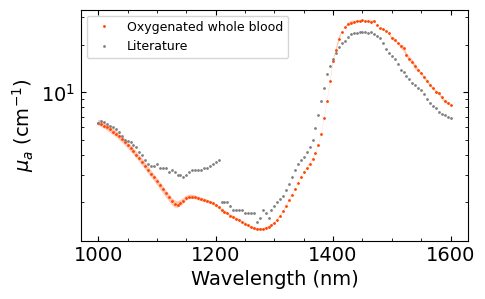

In [32]:
# WHOLE BLOOD OXY

#450 - 1599nm
WB_OXY_wvl, WB_OXY_meas, WB_OXY_meas_std, WB_OXY_lit = interpolate(1000, 1600, 5, inhouseSIS['nm'], inhouseSIS['WB_S_oxy_mua'], inhouseSIS['WB_S_oxy_mua_std'], whole_blood_ref['nm'], whole_blood_ref['mua_oxy[mm-1]']*10)

# plot
plot_interp(WB_OXY_wvl, WB_OXY_meas, WB_OXY_meas_std, WB_OXY_lit, 'orangered', 'Oxygenated whole blood')

# stats 
WB_OXY_stats_SWIR = run_stats(WB_OXY_meas, WB_OXY_meas_std, WB_OXY_lit, 'WB_OXY_SWIR')


SAM score is 0.1032 ± 0.0056
Pearsons r =  0.9925  & p =  0.0  95% CI = [ 0.9891 0.9949 ]
RMSE =  26.0  ±  5.8


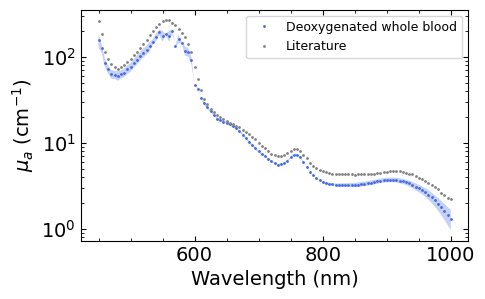

In [33]:
# WHOLE BLOOD DEOXY

#450 - 1599nm
WB_DEOXY_wvl, WB_DEOXY_meas, WB_DEOXY_meas_std, WB_DEOXY_lit = interpolate(450, 1000, 5, inhouseSIS['nm'], inhouseSIS['WB_S_deoxy_mua'], inhouseSIS['WB_S_deoxy_mua_std'], whole_blood_ref['nm'], whole_blood_ref['mua_deoxy[mm-1]']*10)

# plot
plot_interp(WB_DEOXY_wvl, WB_DEOXY_meas, WB_DEOXY_meas_std, WB_DEOXY_lit, 'royalblue', 'Deoxygenated whole blood')

# stats 
WB_DEOXY_stats_vis = run_stats(WB_DEOXY_meas, WB_DEOXY_meas_std, WB_DEOXY_lit, 'WB_DEOXY_vis')


SAM score is 0.1204 ± 0.0075
Pearsons r =  0.9911  & p =  0.0  95% CI = [ 0.9872 0.9938 ]
RMSE =  1.3  ±  0.1


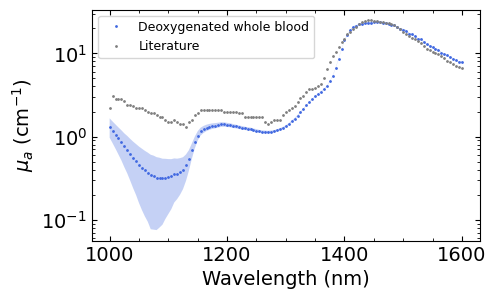

In [34]:
# WHOLE BLOOD DEOXY

#450 - 1599nm
WB_DEOXY_wvl, WB_DEOXY_meas, WB_DEOXY_meas_std, WB_DEOXY_lit = interpolate(1000, 1600, 5, inhouseSIS['nm'], inhouseSIS['WB_S_deoxy_mua'], inhouseSIS['WB_S_deoxy_mua_std'], whole_blood_ref['nm'], whole_blood_ref['mua_deoxy[mm-1]']*10)

# plot
plot_interp(WB_DEOXY_wvl, WB_DEOXY_meas, WB_DEOXY_meas_std, WB_DEOXY_lit, 'royalblue', 'Deoxygenated whole blood')

# stats 
WB_DEOXY_stats_SWIR = run_stats(WB_DEOXY_meas, WB_DEOXY_meas_std, WB_DEOXY_lit, 'WB_DEOXY_SWIR')


SAM score is 0.032 ± 0.0
Pearsons r =  0.9991  & p =  0.0  95% CI = [ 0.9986 0.9995 ]
RMSE =  127.7  ±  0.0


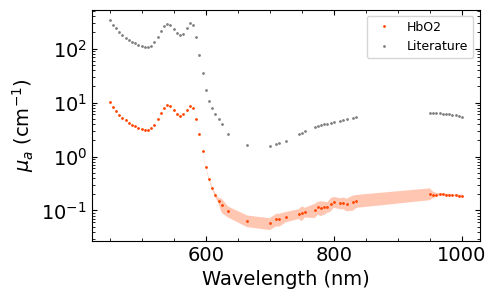

In [35]:
# HbO2 in D2O 450-1000nm

#450 - 1599nm
HbO2_wvl, HbO2_meas, HbO2_meas_std, HbO2_lit = interpolate(450, 1000, 5, shimadzu['nm'], shimadzu['HbO2_mua'], shimadzu['HbO2_std'], HbO2_wavelengths_ref, HbO2_mua_ref)

# plot
plot_interp(HbO2_wvl, HbO2_meas, HbO2_meas_std, HbO2_lit, 'orangered', 'HbO2')

# stats 
HbO2_stats_vis = run_stats(HbO2_meas, HbO2_meas_std, HbO2_lit, 'HbO2_vis')


SAM score is 0.2567 ± 0.0011
Pearsons r =  0.9594  & p =  0.0  95% CI = [ 0.9393 0.973 ]
RMSE =  116.8  ±  0.0


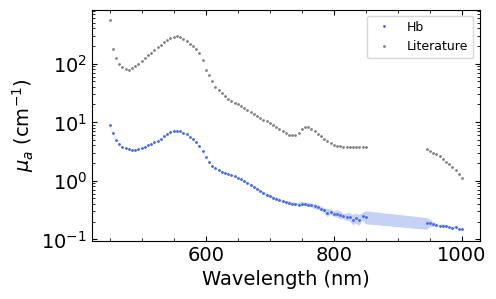

In [36]:
# Hb in D2O 450-1000nm

#450 - 1599nm
Hb_wvl, Hb_meas, Hb_meas_std, Hb_lit = interpolate(450, 1000, 5, shimadzu['nm'], shimadzu['Hb_mua'], shimadzu['Hb_std'], Hb_wavelengths_ref, Hb_mua_ref)

# plot
plot_interp(Hb_wvl, Hb_meas, Hb_meas_std, Hb_lit, 'royalblue', 'Hb')

# stats 
Hb_stats_vis = run_stats(Hb_meas, Hb_meas_std, Hb_lit, 'Hb_vis')


SAM score is 0.3356 ± 0.0585
Pearsons r =  0.8602  & p =  0.0  95% CI = [ 0.7566 0.9217 ]
RMSE =  0.0  ±  0.0


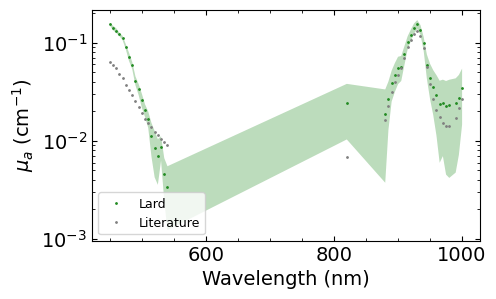

In [37]:
# Lard

#450 - 1599nm
lard_wvl, lard_meas, lard_meas_std, lard_lit = interpolate(450, 1000, 5, inhouseSIS['nm'], inhouseSIS['lard_mua'], inhouseSIS['lard_mua_std'], fat_ref['nm'], fat_ref['mua[cm-1]'])

# plot
plot_interp(lard_wvl, lard_meas, lard_meas_std, lard_lit, 'forestgreen', 'Lard')

# stats 
lard_stats_vis = run_stats(lard_meas, lard_meas_std, lard_lit, 'lard_vis')


SAM score is 0.1188 ± 0.0111
Pearsons r =  0.9875  & p =  0.0  95% CI = [ 0.9821 0.9913 ]
RMSE =  0.1  ±  0.0


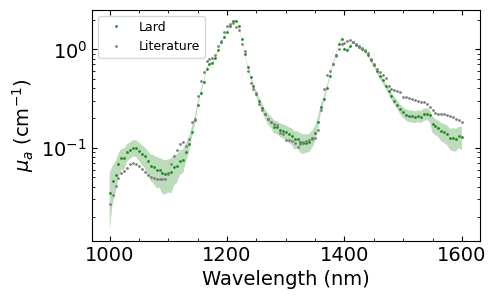

In [38]:
# Lard

#450 - 1599nm
lard_wvl, lard_meas, lard_meas_std, lard_lit = interpolate(1000, 1600, 5, inhouseSIS['nm'], inhouseSIS['lard_mua'], inhouseSIS['lard_mua_std'], fat_ref['nm'], fat_ref['mua[cm-1]'])

# plot
plot_interp(lard_wvl, lard_meas, lard_meas_std, lard_lit, 'forestgreen', 'Lard')

# stats 
lard_stats_SWIR = run_stats(lard_meas, lard_meas_std, lard_lit, 'lard_SWIR')


SAM score is 0.0858 ± 0.0015
Pearsons r =  0.993  & p =  0.0  95% CI = [ 0.99 0.9951 ]
RMSE =  0.1  ±  0.0


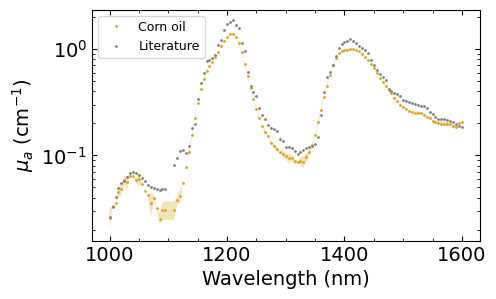

In [39]:
# Corn oil

#250 - 2500nm
cornoil_wvl, cornoil_meas, cornoil_meas_std, cornoil_lit = interpolate(1000, 1600, 5, shimadzu['nm'], shimadzu['corn_oil_mua'], shimadzu['corn_oil_std'], fat_ref['nm'], fat_ref['mua[cm-1]'])

# plot
plot_interp(cornoil_wvl, cornoil_meas, cornoil_meas_std, cornoil_lit, 'goldenrod', 'Corn oil')

# stats 
cornoil_stats_SWIR = run_stats(cornoil_meas, cornoil_meas_std, cornoil_lit, 'cornoil_SWIR')

SAM score is 0.8694 ± 0.0306
Pearsons r =  -0.0082  & p =  0.9662  95% CI = [ -0.3736 0.3594 ]
RMSE =  0.2  ±  0.0


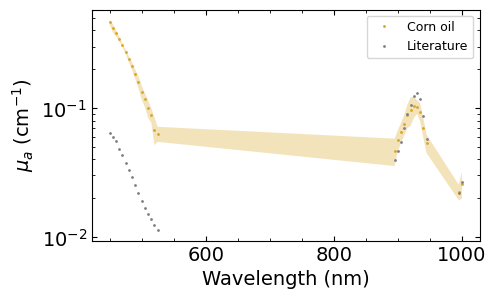

In [40]:
# Corn oil

#450 - 1000nm
cornoil_wvl, cornoil_meas, cornoil_meas_std, cornoil_lit = interpolate(450, 1000, 5, shimadzu['nm'], shimadzu['corn_oil_mua'], shimadzu['corn_oil_std'], fat_ref['nm'], fat_ref['mua[cm-1]'])

# plot
plot_interp(cornoil_wvl, cornoil_meas, cornoil_meas_std, cornoil_lit, 'goldenrod', 'Corn oil')

# stats 
cornoil_stats_vis = run_stats(cornoil_meas, cornoil_meas_std, cornoil_lit, 'cornoil_vis')

SAM score is 0.0845 ± 0.0072
Pearsons r =  0.9957  & p =  0.0  95% CI = [ 0.9945 0.9967 ]
RMSE =  32.5  ±  3.1


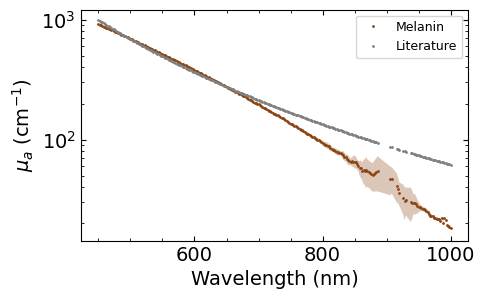

In [41]:
# Melanin
#250 - 2500nm
melanin_wvl, melanin_meas, melanin_meas_std, melanin_lit = interpolate(450, 1000, 2, shimadzu['nm'], shimadzu['melanin_DMSO_mua'], shimadzu['melanin_DMSO_std'], melanin_mua_ref['nm'], melanin_mua_ref['mua[cm-1]'])

# plot
plot_interp(melanin_wvl, melanin_meas, melanin_meas_std, melanin_lit, 'saddlebrown', 'Melanin')

# stats 
melanin_stats_vis = run_stats(melanin_meas, melanin_meas_std, melanin_lit, 'melanin_vis')

SAM score is 0.3504 ± 0.022
Pearsons r =  0.7148  & p =  0.0  95% CI = [ 0.6434 0.7739 ]
RMSE =  27.0  ±  0.6


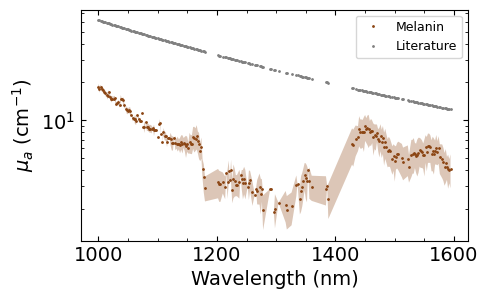

In [42]:
# Melanin
#250 - 2500nm
melanin_wvl, melanin_meas, melanin_meas_std, melanin_lit = interpolate(1000, 1600, 2, shimadzu['nm'], shimadzu['melanin_DMSO_mua'], shimadzu['melanin_DMSO_std'], melanin_mua_ref['nm'], melanin_mua_ref['mua[cm-1]'])

# plot
plot_interp(melanin_wvl, melanin_meas, melanin_meas_std, melanin_lit, 'saddlebrown', 'Melanin')

# stats 
melanin_stats_SWIR = run_stats(melanin_meas, melanin_meas_std, melanin_lit, 'melanin_SWIR')

# Format to copy into LaTex table

In [43]:
def latex_vis_SWIR(name, stats_vis, stats_SWIR):

    print('\multirow{2}{*}{',name,'} & 450\,-\,1000 & ', stats_vis[1], '\,±\,', stats_vis[2], ' & ', stats_vis[3], ', CI = [', stats_vis[5], ', ', stats_vis[6], '] & ', stats_vis[7], '\,±\,', stats_vis[8],' & ref \\',
    '& 1000\,-\,1600 & ', stats_SWIR[1], '\,±\,', stats_SWIR[2], ' & ', stats_SWIR[3], ' CI = [', stats_SWIR[5], ', ', stats_SWIR[6], '] & ', stats_SWIR[7], '\,±\,', stats_SWIR[8],' & ref \\')

    return

def latex_vis(name, stats_vis):

    print('\multirow{1}{*}{',name,'} & 450\,-\,1000 & ', stats_vis[1], '\,±\,', stats_vis[2], ' & ', stats_vis[3], ', CI = [', stats_vis[5], ', ', stats_vis[6], '] & ', stats_vis[7], '\,±\,', stats_vis[8],' & ref \\')

    return

def latex_SWIR(name, stats_SWIR):

    print('\multirow{1}{*}{',name,'} & 1000\,-\,1600 & ', stats_SWIR[1], '\,±\,', stats_SWIR[2], ' & ', stats_SWIR[3], ', CI = [', stats_SWIR[5], ', ', stats_SWIR[6], '] & ', stats_SWIR[7], '\,±\,', stats_SWIR[8],' & ref \\')

    return

def latex_water(name, stats_A, stats_B):

    print('\multirow{2}{*}{',name,'} & 1000\,-\,1600 & ', stats_A[1], '\,±\,', stats_A[2], ' & ', stats_A[3], ', CI = [', stats_A[5], ', ', stats_A[6], '] & ', stats_A[7], '\,±\,', stats_A[8],' & ref \\',
    '& 1000\,-\,1600 & ', stats_B[1], ',\,±\,', stats_B[2], ' & ', stats_B[3], ' CI=[', stats_B[5], ', ', stats_B[6], '] & ', stats_B[7], '\,±\,', stats_B[8],' & ref \\')

    return

latex_water('H$_2$O', H2O_stats_SWIR, H2O_stats_SWIR2)
latex_SWIR('H$_2$O (Tao)', H2O_stats_SWIR3)
latex_SWIR('D$_2$O', D2O_stats)
latex_vis_SWIR('Oxygenated whole blood', WB_OXY_stats_vis, WB_OXY_stats_SWIR)
latex_vis_SWIR('Deoxygenated whole blood', WB_DEOXY_stats_vis, WB_DEOXY_stats_SWIR)
latex_vis('Oxygenated haemoglobin', HbO2_stats_vis)
latex_vis('Deoxygenated haemoglobin', Hb_stats_vis)
latex_SWIR('Corn oil', cornoil_stats_SWIR)
latex_SWIR('Lard', lard_stats_SWIR)
latex_vis_SWIR('Synthetic melanin', melanin_stats_vis, melanin_stats_SWIR)

\multirow{2}{*}{ H$_2$O } & 1000\,-\,1600 &  0.10738 \,±\, 0.00065  &  0.991 , CI = [ 0.989 ,  0.993 ] &  1.341 \,±\, 0.002  & ref \ & 1000\,-\,1600 &  0.09678 ,\,±\, 0.00283  &  0.993  CI=[ 0.991 ,  0.994 ] &  1.716 \,±\, 0.015  & ref \
\multirow{1}{*}{ H$_2$O (Tao) } & 1000\,-\,1600 &  0.12176 \,±\, 0.00016  &  0.989 , CI = [ 0.986 ,  0.991 ] &  2.098 \,±\, 0.017  & ref \
\multirow{1}{*}{ D$_2$O } & 1000\,-\,1600 &  0.09943 \,±\, 0.00042  &  0.992 , CI = [ 0.99 ,  0.994 ] &  0.031 \,±\, 0.003  & ref \
\multirow{2}{*}{ Oxygenated whole blood } & 450\,-\,1000 &  0.04265 \,±\, 0.00272  &  0.999 , CI = [ 0.998 ,  0.999 ] &  15.864 \,±\, 1.067  & ref \ & 1000\,-\,1600 &  0.14053 \,±\, 0.00074  &  0.986  CI = [ 0.98 ,  0.99 ] &  2.471 \,±\, 0.149  & ref \
\multirow{2}{*}{ Deoxygenated whole blood } & 450\,-\,1000 &  0.10316 \,±\, 0.00556  &  0.993 , CI = [ 0.989 ,  0.995 ] &  26.049 \,±\, 5.834  & ref \ & 1000\,-\,1600 &  0.12044 \,±\, 0.0075  &  0.991  CI = [ 0.987 ,  0.994 ] &  1.278 \,±

# Summary table

In [44]:
stats_table = [H2O_stats_vis, H2O_stats_SWIR, H2O_stats_SWIR2, H2O_stats_SWIR3, D2O_stats, WB_OXY_stats_vis, WB_OXY_stats_SWIR, WB_DEOXY_stats_vis, WB_DEOXY_stats_SWIR, HbO2_stats_vis, Hb_stats_vis, lard_stats_vis , lard_stats_SWIR, cornoil_stats_vis, cornoil_stats_SWIR, melanin_stats_vis, melanin_stats_SWIR]
stats_df = pd.DataFrame(stats_table, columns=['Biomolecule', 'SAM', 'SAM error', 'Pearsons R', 'p', 'CI lower', 'CI upper', 'RMSE', 'RMSE error'])
stats_df
#stats_df.to_csv('stats.csv', sep=',', index=False)

,Biomolecule,SAM,SAM error,Pearsons R,p,CI lower,CI upper,RMSE,RMSE error
0,H2O_vis,0.13410,0.03459,0.961,0.000,0.930,0.979,0.048,0.013
1,H2O_SWIR,0.10738,0.00065,0.991,0.000,0.989,0.993,1.341,0.002
2,H2O_SWIR_Shimadzu-Ran,0.09678,0.00283,0.993,0.000,0.991,0.994,1.716,0.015
3,H2O_SWIR_Ran-Segelstein,0.12176,0.00016,0.989,0.000,0.986,0.991,2.098,0.017
4,D2O_SWIR,0.09943,0.00042,0.992,0.000,0.990,0.994,0.031,0.003
5,WB_OXY_vis,0.04265,0.00272,0.999,0.000,0.998,0.999,15.864,1.067
6,WB_OXY_SWIR,0.14053,0.00074,0.986,0.000,0.980,0.990,2.471,0.149
7,WB_DEOXY_vis,0.10316,0.00556,0.993,0.000,0.989,0.995,26.049,5.834
8,WB_DEOXY_SWIR,0.12044,0.00750,0.991,0.000,0.987,0.994,1.278,0.082
9,HbO2_vis,0.03198,0.00002,0.999,0.000,0.999,0.999,127.696,0.019
